# Data Preprocessing



In [ ]:
from google.colab import drive
from google.colab import files
uploaded = files.upload()

Saving AIvsHumanDataset 2.csv to AIvsHumanDataset 2 (1).csv


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix, hstack
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#------------------------
#Loading the Data Set
#------------------------

DataFrame = pd.read_csv("AIvsHumanDataset 2.csv", sep = ';')
DataFrame.head() #By deafault this func. shows the first 5 rows
DataFrame.info() #Prints the datatype,# of the rows and columns,non-null values,memory usage.
DataFrame.isnull().sum() #Shows the sum of the null values in the each column

print(DataFrame.head())
print("Dataset Shape:", DataFrame.shape)
print("Columns:", DataFrame.columns.tolist())
print("Missing Values", DataFrame.isnull().sum())

#------------------------
#Text Normalization
#----------------------
#In our data set we handling sente so that extra padding and spacing should normalize because furthmore phase like feature extraction wrong tokenization can be done
#with this step noise is decrease and model ca focus on real pattern
def NormalizeText(text): #We using this func. at the feature extraction phase important pattern can seen and with this its decrease the noise
    if pd.isna(text) : #Another verification for prevent model crashing because of the null values
        return " "
    text = str(text)
    text = re.sub(r'[\n\r]+', ' ', text) #Remove multiple paragraph in the text amd make it as whole
    text = re.sub(r'\s+', ' ', text) #Remove extra whitespaces
    return text.strip()#Remove the extra space at beginning and end in the text and return that into

DataFrame['text_combined'] = DataFrame['Text'].apply(NormalizeText)



#Description : In this part ensures balanced text lengths for features extrecation, computational efficiency and normalized data set
word_counts = []

for text in DataFrame['text_combined']:
    words = str(text).split()
    num_words = len(words)
    word_counts.append(num_words)

DataFrame['word_count'] = word_counts

word_counts = DataFrame['word_count']
total_texts = len(DataFrame)


# Target range analysis
TargetCount = 0
TotalTextCount = 0
RowNumber = 0
FilteredList = []

for count in DataFrame['word_count'] :
    if (150 <= count <= 200) :
        TargetCount += 1

    if (count >= 50) :  #The text total words number less than 50 should delete because this text doesnt give sufficient features and make nonsense noise
        NewRow = [ DataFrame.iloc[RowNumber]['text_combined'], DataFrame.iloc[RowNumber]['Class'], count]
        FilteredList.append(NewRow)
        TotalTextCount += 1

    RowNumber += 1

target_percentage = (TargetCount / TotalTextCount) * 100
#This percentage will be efficient in model learning interpreter step, we can understand is the vast majority of the yield is in the ideal range
DFFiltered = pd.DataFrame(FilteredList, columns=['text_combined', 'Class', 'word_count'])

print("Example word counts:", DataFrame['word_count'].head().tolist())
print("Texts >= 50 words:", TotalTextCount)
print("Texts between 150–200 words:", TargetCount, f"({target_percentage:.2f}%)")

#------------------------
# Data Cleaning
#----------------------
#Description : Increase the model accuracy, prevent model crash because of the null values and overfitting data cleaning phase is done

DFFiltered.dropna(inplace=True) #Cleaning the missing values in the data set otherwise model can crash

DFFiltered = DFFiltered.drop_duplicates(subset=['text_combined'])
#With drop_duplicates duplicated text will drop and with this one of the reasons for overfitting is handled otherwise model will learn the noise
#pattern and when test data given model cant accurately generalize the test set

DFFiltered = DFFiltered.sample(frac=1, random_state=42).reset_index(drop=True) #Ensure cross validation and prevent bias


#------------------------
# Label Encoding
#------------------------
#Ensure data type consistency making the model fit For Input Format
DFFiltered["Class"] = DFFiltered["Class"].astype(int)
y = DFFiltered["Class"]

#------------------------
# Feature Extraction - TF-IDF
#------------------------
#Words represented as numeric values according to their importance and features ngram, model can observed words combination, capture the context, recognize the phrasel pattern of AI and human
#incresed the ngram can cause overfitting so that two phrasel pattern is chosen
tfidf_With = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words=None)
X_With = tfidf_With.fit_transform(DFFiltered["text_combined"])

print("TF-IDF No-Stop shape:", X_With.shape)


tfidf_Without = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words= "english")
X_Without = tfidf_Without.fit_transform(DFFiltered["text_combined"])


print("TF-IDF Stop shape:", X_Without.shape)

#This distinction between data set with stop word and without stop word effect will observed in this distintion in model learning phase
#with stop words model may much more detailed and generealized, without stop words model may focused on real effective features


#Reason for using manuel extraction, the features cant cache by TF-IDF will add with this

#1)avg_sentence_length : Human have more tendency to make extra short or extra long, irregular sentences structure thought AI have more tendency to forms a stable, rhythmic length sentences structure

#2)lexical_diversty : This rate is generally higher for AI. because AI uses a wide range of vocabulary unlike people repeat words

#3)punctuation_Density : AI makes more regular punctuation.

#4)Capitalized_Ratio : AI texts uses fewer custom names, produces words starting with fewer capital letters unlike human writings, it starts with a capital letter -name, institution, city, person, etc.-
#therefore, it is a very distinctive feature.

#5)Pronoun_Ratio : One of the strongest signals for the model distinct the AI and human text. AI avoids personal pronouns like I, we, my, our, me. People use it a lot because it makes personal expression.

#6) Num_Sentences : For example ın two texts of the same length, human makes much more short and frequent sentences this is otherwise for AI

def extract_manual_features(text):
    text = str(text)
    words = text.split()

    num_words = 0
    for w in words:
        num_words += 1
#Number of sentences :
    raw_sentences = re.split(r"[.!?]", text)
    cleaned_sentences = []
    for s in raw_sentences:
        stripped_sentence = s.strip()
        if len(stripped_sentence) > 0:
            cleaned_sentences.append(stripped_sentence)

    num_sentences = 0
    for s in cleaned_sentences:
        num_sentences += 1

    if num_sentences > 0:
        avg_sentence_length = num_words / num_sentences
    else:
        avg_sentence_length = 0

    unique_set = []
    for w in words:
        if w not in unique_set:
            unique_set.append(w)

    unique_words = 0
    for w in unique_set:
        unique_words += 1

    if num_words > 0:
        lexical_diversity = unique_words / num_words
    else:
        lexical_diversity = 0


    punctuation_marks = ".,;:!?"
    punctuation_count = 0

    for c in text:
        if c in punctuation_marks:
            punctuation_count += 1

    if num_words > 0:
        punctuation_density = punctuation_count / num_words
    else:
        punctuation_density = 0

    capitalized_words = 0
    for w in words:
        if len(w) > 1 and w[0].isupper():
            capitalized_words += 1

    if num_words > 0:
        capitalized_ratio = capitalized_words / num_words
    else:
        capitalized_ratio = 0


    pronoun_list = ['i', 'we', 'my', 'our', 'us', 'their']

    personal_pronouns = 0
    for w in words:
        if w.lower() in pronoun_list:
            personal_pronouns += 1

    if num_words > 0:
        pronoun_ratio = personal_pronouns / num_words
    else:
        pronoun_ratio = 0

    return [avg_sentence_length, lexical_diversity, punctuation_density, capitalized_ratio, pronoun_ratio, num_sentences]



manual_features = DFFiltered["text_combined"].apply(extract_manual_features)
manual_features = np.vstack(manual_features.values)

manual_df = pd.DataFrame(manual_features, columns=['Avg_Sentence_Length', 'Lexical_Diversity', 'Punctuation_Density', 'Capitalized_Ratio', 'Pronoun_Ratio','Num_Sentences'])
DFFiltered = pd.concat([DFFiltered, manual_df], axis=1)


print("Manual features shape:", manual_features.shape)
print("Example manual features (first row):", manual_features[0])



#------------------------
# Feature Combination
#------------------------
manual_features_sparse = csr_matrix(manual_features)
X_combined_With = hstack([X_With, manual_features_sparse])
X_combined_Without = hstack([X_Without, manual_features_sparse])

#------------------------
# EDA Graph
#------------------------

plt.style.use('default')
sns.set_palette("husl")
plt.figure(figsize=(15, 12))

#First we plot the number AI nad human tetx as chart bar
plt.subplot(2, 3, 1)
class_distribution = DFFiltered['Class'].value_counts()
plt.bar(['AI', 'Human'], class_distribution.values, color=['pink', 'blue'])
plt.title('Class Distribution (AI vs Human)')
plt.ylabel('Number of Texts')

i = 0
while i < 2:
    plt.text(i, class_distribution.values[i], str(class_distribution.values[i]), ha='center', va='bottom')
    i += 1


#This graph plot the number of 150<= text number <= 200
plt.subplot(2, 3, 2)
plt.hist(DFFiltered['word_count'], bins = 30, alpha = 0.5, color = 'skyblue', edgecolor = 'black')
plt.axvline(150, color = 'red', linestyle ='dashed', alpha = 0.8, label = '150 words')
plt.axvline(200, color = 'red', linestyle = 'dashed', alpha = 0.8, label = '200 words')
plt.xlabel('Word Count')
plt.ylabel('NUmber of Text')
plt.title('Word Count Distribution')
plt.legend()


#For comparing the number of words in AI text and human text
plt.subplot(2, 3, 3)
sns.boxplot(x = 'Class', y='word_count', data = DFFiltered)
plt.title('Word Count: AI vs Human')
plt.xticks([0, 1], ['AI', 'Human'])
plt.ylabel('Word Count')


#Plot the manula feature that extracted with this graph we can understand multicollinearity
plt.subplot(2, 3, 4)
manual_df['label'] = y.values
correlation_matrix = manual_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap = 'coolwarm', center=0, fmt = '.2f')
plt.title('Manual Features Correlation')


#Shows the variety of words useage in AI and human text
plt.subplot(2, 3, 5)
sns.boxplot(x = 'Class', y = 'Lexical_Diversity', data = DFFiltered)
plt.title('Lexical Diversity: AI vs Human')
plt.xticks([0, 1], ['AI', 'Human'])
plt.ylabel('Lexical Diversity')


plt.subplot(2, 3, 6)
sns.violinplot(x = 'Class', y = 'Punctuation_Density', data = DFFiltered)
plt.title('Punctuation Density: AI vs Human')
plt.xticks([0, 1], ['AI', 'Human'])
plt.ylabel('Punctuation Density')


print(DFFiltered.describe())
plt.tight_layout()
plt.show()

# Logistic Regression (With Stop Word)

In [ ]:
# ============================================================
# COE305 - Machine Learning
# Stage 3: Model Building & Baseline Evaluation
# Model: Logistic Regression
# Data: Google Sheets (Text, Label)
# Split: 70% Train / 30% Test
# CV: 5-Fold Stratified
# Features: TF-IDF (1-2 grams, 5000 features)
# ============================================================

import pandas as pd
import re
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# ----------------------------
# 1) Load dataset from Google Sheets (CSV export)
# ----------------------------
SHEET_ID = "1G2xr1kQXkWII3olI_akMQa_HsBgfRNqFhyIL2S1wdRU"
CSV_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv"

df = pd.read_csv(CSV_URL)

TEXT_COL = "Text"
LABEL_COL = "Label"   # 0 = AI, 1 = Human

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

# ----------------------------
# 2) Text normalization (basic cleaning)
# ----------------------------
def normalize_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"[\n\r]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df[TEXT_COL] = df[TEXT_COL].apply(normalize_text)
df = df[df[TEXT_COL].str.len() > 0].reset_index(drop=True)

y = df[LABEL_COL].astype(int).values

# ----------------------------
# 3) Feature extraction: TF-IDF
# ----------------------------
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words = None )
X = tfidf.fit_transform(df[TEXT_COL])

print("TF-IDF shape:", X.shape)

# ----------------------------
# 4) Train-test split (70/30)
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])

# ----------------------------
# 5) Model definition
# ----------------------------
model = LogisticRegression(solver="liblinear", random_state=42, max_iter=2000)

# ----------------------------
# 6) Cross-validation on training set (5-fold stratified)
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1"}

cv_results = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)

print("\n=== 5-Fold Stratified CV Results (TRAIN, Mean ± SD) ===")
for m in ["accuracy", "precision", "recall", "f1"]:
    mean = cv_results[f"test_{m}"].mean()
    sd = cv_results[f"test_{m}"].std()
    print(f"{m.upper():9s}: {mean:.4f} ± {sd:.4f}")

# ----------------------------
# 7) Final training and evaluation on test set
# ----------------------------
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# AUC requires predicted probabilities
y_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print("\n=== TEST Results ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"AUC      : {auc:.4f}")

print("\nClassification Report (TEST):")
print(classification_report(y_test, y_pred, target_names=["AI(0)", "Human(1)"]))

print("Confusion Matrix (TEST):")
print(confusion_matrix(y_test, y_pred))


Dataset shape: (969, 2)
Columns: ['Text', 'Label']
TF-IDF shape: (969, 5000)
Train size: 678 Test size: 291

=== 5-Fold Stratified CV Results (TRAIN, Mean ± SD) ===
ACCURACY : 0.9409 ± 0.0183
PRECISION: 0.9436 ± 0.0235
RECALL   : 0.9431 ± 0.0254
F1       : 0.9430 ± 0.0177

=== TEST Results ===
Accuracy : 0.9485
Precision: 0.9304
Recall   : 0.9735
F1-Score : 0.9515
AUC      : 0.9763

Classification Report (TEST):
              precision    recall  f1-score   support

       AI(0)       0.97      0.92      0.95       140
    Human(1)       0.93      0.97      0.95       151

    accuracy                           0.95       291
   macro avg       0.95      0.95      0.95       291
weighted avg       0.95      0.95      0.95       291

Confusion Matrix (TEST):
[[129  11]
 [  4 147]]


# Logistic Regression (Without Stop Word)

In [ ]:
# ============================================================
# COE305 - Machine Learning
# Stage 3: Model Building & Baseline Evaluation
# Model: Logistic Regression
# Data: Google Sheets (Text, Label)
# Split: 70% Train / 30% Test
# CV: 5-Fold Stratified
# Features: TF-IDF (1-2 grams, 5000 features)
# ============================================================

import pandas as pd
import re
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# ----------------------------
# 1) Load dataset from Google Sheets (CSV export)
# ----------------------------
SHEET_ID = "1G2xr1kQXkWII3olI_akMQa_HsBgfRNqFhyIL2S1wdRU"
CSV_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv"

df = pd.read_csv(CSV_URL)

TEXT_COL = "Text"
LABEL_COL = "Label"   # 0 = AI, 1 = Human

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

# ----------------------------
# 2) Text normalization (basic cleaning)
# ----------------------------
def normalize_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"[\n\r]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df[TEXT_COL] = df[TEXT_COL].apply(normalize_text)
df = df[df[TEXT_COL].str.len() > 0].reset_index(drop=True)

y = df[LABEL_COL].astype(int).values

# ----------------------------
# 3) Feature extraction: TF-IDF (WITHOUT STOP WORDS)
# ----------------------------
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english"   # <-- TEK DEĞİŞİKLİK
)

X = tfidf.fit_transform(df[TEXT_COL])

print("TF-IDF shape:", X.shape)

# ----------------------------
# 4) Train-test split (70/30)
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])

# ----------------------------
# 5) Model definition
# ----------------------------
model = LogisticRegression(solver="liblinear", random_state=42, max_iter=2000)

# ----------------------------
# 6) Cross-validation on training set (5-fold stratified)
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1"}

cv_results = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)

print("\n=== 5-Fold Stratified CV Results (TRAIN, Mean ± SD) ===")
for m in ["accuracy", "precision", "recall", "f1"]:
    mean = cv_results[f"test_{m}"].mean()
    sd = cv_results[f"test_{m}"].std()
    print(f"{m.upper():9s}: {mean:.4f} ± {sd:.4f}")

# ----------------------------
# 7) Final training and evaluation on test set
# ----------------------------
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# AUC requires predicted probabilities
y_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print("\n=== TEST Results ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"AUC      : {auc:.4f}")

print("\nClassification Report (TEST):")
print(classification_report(y_test, y_pred, target_names=["AI(0)", "Human(1)"]))

print("Confusion Matrix (TEST):")
print(confusion_matrix(y_test, y_pred))


Dataset shape: (969, 2)
Columns: ['Text', 'Label']
TF-IDF shape: (969, 5000)
Train size: 678 Test size: 291

=== 5-Fold Stratified CV Results (TRAIN, Mean ± SD) ===
ACCURACY : 0.9351 ± 0.0107
PRECISION: 0.9209 ± 0.0161
RECALL   : 0.9573 ± 0.0178
F1       : 0.9386 ± 0.0100

=== TEST Results ===
Accuracy : 0.9416
Precision: 0.9408
Recall   : 0.9470
F1-Score : 0.9439
AUC      : 0.9751

Classification Report (TEST):
              precision    recall  f1-score   support

       AI(0)       0.94      0.94      0.94       140
    Human(1)       0.94      0.95      0.94       151

    accuracy                           0.94       291
   macro avg       0.94      0.94      0.94       291
weighted avg       0.94      0.94      0.94       291

Confusion Matrix (TEST):
[[131   9]
 [  8 143]]


# Support Vector (Machine With Stop Word)

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y = DFFiltered["Class"] # Redefine y to match the DFFiltered DataFrame

# -------------------------------
# Train-Test Split (WITH Stopwords)
# -------------------------------
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_combined_With,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# -------------------------------
# SVM WITH Stopwords
# -------------------------------
svm_stop = LinearSVC(C=1.0, max_iter=10000)

svm_stop_scores = cross_validate(
    svm_stop,
    X_combined_With,
    y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"]
)

print("\n===== TRAIN RESULTS (CV) – SVM WITH Stopwords =====")
print("Accuracy (mean ± std):",
      svm_stop_scores["test_accuracy"].mean(),
      "±",
      svm_stop_scores["test_accuracy"].std())
print("Precision (mean):", svm_stop_scores["test_precision"].mean())
print("Recall (mean):", svm_stop_scores["test_recall"].mean())
print("F1-score (mean):", svm_stop_scores["test_f1"].mean())

# TEST
svm_stop.fit(X_train_s, y_train_s)
y_pred_s = svm_stop.predict(X_test_s)

print("\n===== TEST RESULTS – SVM WITH Stopwords =====")
print("Accuracy :", accuracy_score(y_test_s, y_pred_s))
print("Precision:", precision_score(y_test_s, y_pred_s))
print("Recall   :", recall_score(y_test_s, y_pred_s))
print("F1-score :", f1_score(y_test_s, y_pred_s))

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



===== TRAIN RESULTS (CV) – SVM WITH Stopwords =====
Accuracy (mean ± std): 0.9610180623973728 ± 0.011093866325828643
Precision (mean): 0.9630402074600418
Recall (mean): 0.9584068430900828
F1-score (mean): 0.9605833187620213

===== TEST RESULTS – SVM WITH Stopwords =====
Accuracy : 0.9618320610687023
Precision: 0.96875
Recall   : 0.9538461538461539
F1-score : 0.9612403100775194


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


# Support Vector Machine (Without Stop Word)

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

# -------------------------------
# Stratified K-Fold
# -------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------------------
# Train-Test Split (WITHOUT Stopwords)
# -------------------------------
X_train_ns, X_test_ns, y_train, y_test = train_test_split(
    X_combined_Without,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# -------------------------------
# SVM WITHOUT Stopwords
# -------------------------------
svm_nostop = LinearSVC(C=1.0, max_iter=10000)

svm_nostop_scores = cross_validate(
    svm_nostop,
    X_combined_Without,
    y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"]
)

print("\n===== TRAIN RESULTS (CV) – SVM WITHOUT Stopwords =====")
print("Accuracy (mean ± std):",
      svm_nostop_scores["test_accuracy"].mean(),
      "±",
      svm_nostop_scores["test_accuracy"].std())
print("Precision (mean):", svm_nostop_scores["test_precision"].mean())
print("Recall (mean):", svm_nostop_scores["test_recall"].mean())
print("F1-score (mean):", svm_nostop_scores["test_f1"].mean())

# TEST
svm_nostop.fit(X_train_ns, y_train)
y_pred_ns = svm_nostop.predict(X_test_ns)

print("\n===== TEST RESULTS – SVM WITHOUT Stopwords =====")
print("Accuracy :", accuracy_score(y_test, y_pred_ns))
print("Precision:", precision_score(y_test, y_pred_ns))
print("Recall   :", recall_score(y_test, y_pred_ns))
print("F1-score :", f1_score(y_test, y_pred_ns))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ns))

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



===== TRAIN RESULTS (CV) – SVM WITHOUT Stopwords =====
Accuracy (mean ± std): 0.9518423645320198 ± 0.013374822811164014
Precision (mean): 0.9607014187788936
Recall (mean): 0.9422346966051858
F1-score (mean): 0.9510267734964091

===== TEST RESULTS – SVM WITHOUT Stopwords =====
Accuracy : 0.9541984732824428
Precision: 0.9609375
Recall   : 0.9461538461538461
F1-score : 0.9534883720930233
Confusion Matrix:
 [[127   5]
 [  7 123]]


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


# Random Forest (With Stop Word)

In [ ]:
#----------------------------------------
#-----------------------------------------
datasets = X_combined_With
y = DFFiltered["Class"] # Hedef değişken [cite: 132]

# Sonuçları saklamak için boş listeler
training_report = [] # Tablo 1 için (Cross Validation)
testing_report = []  # Tablo 2 için (Test Seti)

X_train, X_test, Y_train, Y_test = train_test_split(datasets, y, test_size=0.3, random_state=42, stratify=y)
#stratify is used for test data evenly split for 180 AI text and 180 human text otherwise overfitting can occur

#--------------------------------------
# B) Scaling (Ölçeklendirme)
#--------------------------------------
scaler = StandardScaler(with_mean = False) # Because of the TD-IDF features are sparse matrix so that we avoid from calculating the average

X_train_scaled = scaler.fit_transform(X_train)
# With .fit_transform first fit is looin at the each columns and calculate statistic while transform get the this statistic info and use them as a formula
#for standardization each value in X_train

X_test_scaled = scaler.transform(X_test)
# We have to evaluate the test data according to the standards of the training data so that we dont use fit.

#---------------------------------------
# C) Model Tanımlama (Random Forest)
#---------------------------------------
RandomForestModel = RandomForestClassifier(n_estimators=100, random_state=42)

#---------------------------------------
# D) TRAINING PHASE: Cross-Validation (Tablo 1 Verisi)
#---------------------------------------
# Şablonda istenen: Mean ± SD
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Stratified fold used for to ensure each test piece will definitely contain 50% AI, 50% Human.
# Divides the data into 5 parts. Trains and tests the model 5 times.

ModelPerformanceResults= ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
# First divide the data into 5 parts with stratified
# And then train with 4 pieces each time and validate with 1 piece in each iteration with this each part will use as validation set.

cv_results = cross_validate(RandomForestModel, X_train_scaled, Y_train, cv=cv, scoring = ModelPerformanceResults)
training_report.append(
    {
        "Model": "Random Forest",
        "Accuracy": f"{cv_results["test_accuracy"].mean():.3f} ± {cv_results["test_accuracy"].std():.3f}",
        "Precision": cv_results["test_precision_macro"].mean(),
        "Recall": cv_results["test_recall_macro"].mean(),
        "F1-Score": cv_results["test_f1_macro"].mean()
    }
)
#-------------------------------------
# E) TESTING PHASE: Unseen Data (Tablo 2 Verisi)
#-------------------------------------
# Modeli tüm eğitim verisiyle eğitip test setinde deniyoruz.
RandomForestModel.fit(X_train_scaled, Y_train)
y_pred = RandomForestModel.predict(X_test_scaled)

testing_report.append(
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(Y_test, y_pred),
        "Precision": precision_score(Y_test, y_pred, average='macro'),
        "Recall": recall_score(Y_test, y_pred, average='macro'),
        "F1-Score": f1_score(Y_test, y_pred, average='macro')
    }
)

# --- 3. RAPORLAMA ---
df_train_results = pd.DataFrame(training_report)
df_test_results = pd.DataFrame(testing_report)

print("\n--- RAPOR 1: TRAINING RESULTS (Cross-Validation) ---")
print(df_train_results.to_string())

print("\n--- RAPOR 2: TESTING RESULTS (Gerçek Test Verisi) ---")
print(df_test_results.to_string())



# Random Forest (Without Stop Word)

In [ ]:
#-----------------------------------------
datasets = X_combined_Without
y = DFFiltered["Class"] # Hedef değişken [cite: 132]

# Sonuçları saklamak için boş listeler
training_report = [] # Tablo 1 için (Cross Validation)
testing_report = []  # Tablo 2 için (Test Seti)

X_train, X_test, Y_train, Y_test = train_test_split(datasets, y, test_size=0.3, random_state=42, stratify=y)
#stratify is used for test data evenly split for 180 AI text and 180 human text otherwise overfitting can occur

#--------------------------------------
# B) Scaling (Ölçeklendirme)
#--------------------------------------
scaler = StandardScaler(with_mean=False) # Because of the TD-IDF features are sparse matrix so that we avoid from calculating the average

X_train_scaled_without = scaler.fit_transform(X_train)
# With .fit_transform first fit is looin at the each columns and calculate statistic while transform get the this statistic info and use them as a formula
#for standardization each value in X_train

X_test_scaled_without = scaler.transform(X_test)
# We have to evaluate the test data according to the standards of the training data so that we dont use fit.

#---------------------------------------
# C) Model Tanımlama (Random Forest)
#---------------------------------------
RandomForestModel_without = RandomForestClassifier(n_estimators=100, random_state=42)

#---------------------------------------
# D) TRAINING PHASE: Cross-Validation (Tablo 1 Verisi)
#---------------------------------------
# Şablonda istenen: Mean ± SD
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Stratified fold used for to ensure each test piece will definitely contain 50% AI, 50% Human.
# Divides the data into 5 parts. Trains and tests the model 5 times.

ModelPerformanceResults= ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
# First divide the data into 5 parts with stratified
# And then train with 4 pieces each time and validate with 1 piece in each iteration with this each part will use as validation set.

cv_results = cross_validate(RandomForestModel, X_train_scaled, Y_train, cv=cv, scoring = ModelPerformanceResults)
training_report.append(
    {
        "Model": "Random Forest",
        "Accuracy": f"{cv_results["test_accuracy"].mean():.3f} ± {cv_results["test_accuracy"].std():.3f}",
        "Precision": cv_results["test_precision_macro"].mean(),
        "Recall": cv_results["test_recall_macro"].mean(),
        "F1-Score": cv_results["test_f1_macro"].mean()
    }
)
#-------------------------------------
# E) TESTING PHASE: Unseen Data (Tablo 2 Verisi)
#-------------------------------------
# Modeli tüm eğitim verisiyle eğitip test setinde deniyoruz.
RandomForestModel.fit(X_train_scaled, Y_train)
y_pred = RandomForestModel.predict(X_test_scaled)

testing_report.append(
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(Y_test, y_pred),
        "Precision": precision_score(Y_test, y_pred, average='macro'),
        "Recall": recall_score(Y_test, y_pred, average='macro'),
        "F1-Score": f1_score(Y_test, y_pred, average='macro')
    }
)

# --- 3. RAPORLAMA ---
df_train_results = pd.DataFrame(training_report)
df_test_results = pd.DataFrame(testing_report)

print("\n--- RAPOR 1: TRAINING RESULTS (Cross-Validation) ---")
print(df_train_results.to_string())

print("\n--- RAPOR 2: TESTING RESULTS (Gerçek Test Verisi) ---")
print(df_test_results.to_string())



--- RAPOR 1: TRAINING RESULTS (Cross-Validation) ---
           Model       Accuracy  Precision   Recall  F1-Score
0  Random Forest  0.925 ± 0.018   0.925484  0.92482  0.924562

--- RAPOR 2: TESTING RESULTS (Gerçek Test Verisi) ---
           Model  Accuracy  Precision    Recall  F1-Score
0  Random Forest  0.927481   0.927639  0.927564   0.92748


# Voting Classifier

=== Ensemble Learning Models Performance Table (Before Hyperparameter tuning) ===

Regression Metrics (placeholder for classification task):
RMSE: 0.2049, R2: 0.8321, MAE: 0.0420, MAPE: 4.1985

Classification Metrics:
Accuracy : 0.9580
Precision: 1.0000
Recall   : 0.9154
F1-Score : 0.9558


/tmp/ipython-input-1326949079.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_imp_df_top20, palette='Blues_d')


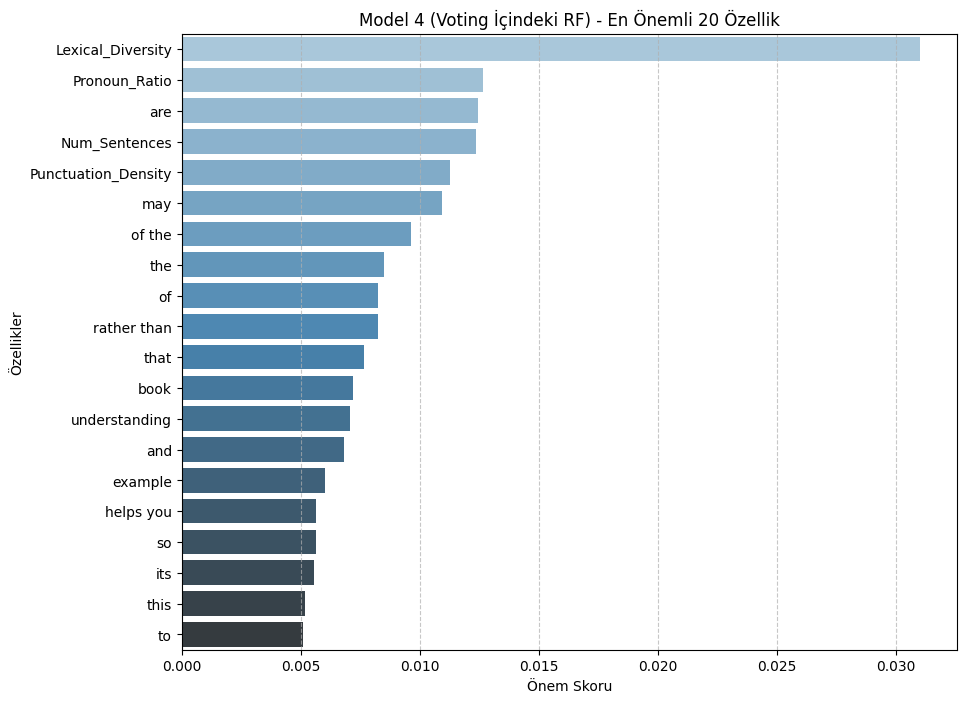



=== Ensemble Learning Models Performance Table (After Hyperparameter tuning) ===

Regression Metrics (placeholder for classification task):
RMSE: 0.1853, R2: 0.8626, MAE: 0.0344, MAPE: 3.4351

Classification Metrics:
Accuracy : 0.9656
Precision: 1.0000
Recall   : 0.9308
F1-Score : 0.9641

Best Hyperparameters Found: {'voting': 'soft', 'weights': [2, 1, 1]}


In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.inspection import permutation_importance

# ----------------------------
# 1. Base Models
# ----------------------------
model = LogisticRegression(solver="liblinear", random_state=42, max_iter=2000)
svm_stop = SVC(probability=True, kernel='rbf', random_state=42)
RandomForestModel = RandomForestClassifier(n_estimators=100, random_state=42)

# ----------------------------
# 2. Ensemble Model (Before Hyperparameter Tuning)
# ----------------------------
voting_clf = VotingClassifier(
    estimators=[('model', model), ('svm_stop', svm_stop), ('RandomForestModel', RandomForestModel)],
    voting='soft',
    weights=[1, 1, 1]
)

voting_clf.fit(X_train_scaled, Y_train)
y_pred_before = voting_clf.predict(X_test_scaled)

# ----------------------------
# 3. Calculate Metrics (Before Tuning)
# ----------------------------
accuracy_b = accuracy_score(Y_test, y_pred_before)
precision_b = precision_score(Y_test, y_pred_before)
recall_b = recall_score(Y_test, y_pred_before)
f1_b = f1_score(Y_test, y_pred_before)

# Regression placeholders (for report table)
rmse_b = np.sqrt(mean_squared_error(Y_test, y_pred_before))
r2_b = r2_score(Y_test, y_pred_before)
mae_b = mean_absolute_error(Y_test, y_pred_before)
mape_b = np.mean(np.abs((Y_test - y_pred_before) / np.clip(Y_test, 1e-5, None))) * 100

print("=== Ensemble Learning Models Performance Table (Before Hyperparameter tuning) ===")
print("\nRegression Metrics (placeholder for classification task):")
print(f"RMSE: {rmse_b:.4f}, R2: {r2_b:.4f}, MAE: {mae_b:.4f}, MAPE: {mape_b:.4f}")

print("\nClassification Metrics:")
print(f"Accuracy : {accuracy_b:.4f}")
print(f"Precision: {precision_b:.4f}")
print(f"Recall   : {recall_b:.4f}")
print(f"F1-Score : {f1_b:.4f}")

# ----------------------------
# 4. Hyperparameter Tuning
# ----------------------------
param_grid = {
    'voting': ['soft', 'hard'],
    'weights': [[1,1,1], [1,2,1], [2,1,1], [1,1,2]]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(estimator=voting_clf, param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, Y_train)

best_voting = grid.best_estimator_
y_pred_after = best_voting.predict(X_test_scaled)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ... (Model eğitim kodların yukarıda kalabilir) ...

# ----------------------------
# Model 4 Feature Importance (DÜZELTİLMİŞ KOD)
# ----------------------------

# 1. Voting Classifier içindeki Random Forest modeline eriş
rf_inside_voting = best_voting.named_estimators_['RandomForestModel']

# 2. Önem Skorlarını Al
importances = rf_inside_voting.feature_importances_

# 3. Özellik İsimlerini Oluştur (HATAYI ÇÖZEN KISIM)
# X_train bir csr_matrix olduğu için .columns çalışmaz.
# İsimleri TF-IDF nesnesinden ve manuel listemizden alıyoruz.

try:
    # Eğer tfidf_With hafızada varsa (önceki hücrelerden):
    tfidf_feature_names = tfidf_With.get_feature_names_out()
    manual_feature_names = ['Avg_Sentence_Length', 'Lexical_Diversity', 'Punctuation_Density', 'Capitalized_Ratio', 'Pronoun_Ratio', 'Num_Sentences']

    # İsimleri birleştir
    feature_names = np.array(list(tfidf_feature_names) + manual_feature_names)

except NameError:
    # Eğer tfidf_With bulunamazsa kodun çökmemesi için jenerik isimler ata
    print("UYARI: 'tfidf_With' değişkeni bulunamadı. Feature_0, Feature_1 gibi isimler atanıyor.")
    feature_names = [f"Feature_{i}" for i in range(len(importances))]

# 4. DataFrame Oluştur ve Sırala
rf_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 5. Sadece En Önemli 20 Özelliği Al
# (Binlerce özellik varsa grafik okunmaz, bu yüzden ilk 20'yi alıyoruz)
rf_imp_df_top20 = rf_imp_df.head(20)

# 6. Görselleştirme
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=rf_imp_df_top20, palette='Blues_d')
plt.title('Model 4 (Voting İçindeki RF) - En Önemli 20 Özellik')
plt.xlabel('Önem Skoru')
plt.ylabel('Özellikler')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()

# ----------------------------
# Kodun geri kalanı (Metrikler) buradan devam eder...
# ----------------------------
# ----------------------------
# 5. Calculate Metrics (After Tuning)
# ----------------------------
accuracy_a = accuracy_score(Y_test, y_pred_after)
precision_a = precision_score(Y_test, y_pred_after)
recall_a = recall_score(Y_test, y_pred_after)
f1_a = f1_score(Y_test, y_pred_after)

rmse_a = np.sqrt(mean_squared_error(Y_test, y_pred_after))
r2_a = r2_score(Y_test, y_pred_after)
mae_a = mean_absolute_error(Y_test, y_pred_after)
mape_a = np.mean(np.abs((Y_test - y_pred_after) / np.clip(Y_test, 1e-5, None))) * 100

print("\n\n=== Ensemble Learning Models Performance Table (After Hyperparameter tuning) ===")
print("\nRegression Metrics (placeholder for classification task):")
print(f"RMSE: {rmse_a:.4f}, R2: {r2_a:.4f}, MAE: {mae_a:.4f}, MAPE: {mape_a:.4f}")

print("\nClassification Metrics:")
print(f"Accuracy : {accuracy_a:.4f}")
print(f"Precision: {precision_a:.4f}")
print(f"Recall   : {recall_a:.4f}")
print(f"F1-Score : {f1_a:.4f}")

# ----------------------------
# 6. Best Parameters
# ----------------------------
print("\nBest Hyperparameters Found:", grid.best_params_)

# Bagging


In [ ]:
# ============================================================
# Bagging Classifier Model (Düzeltilmiş ve Optimize Edilmiş)
# ============================================================
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. Base Model Tanımlama
# -------------------------------
base_estimator = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

# -------------------------------
# 2. Hyperparameter Tuning
# -------------------------------
param_grid = {
    'n_estimators': [50, 100],
    'max_samples': [0.8, 1.0],
    'max_features': [0.8, 1.0],
    'bootstrap': [True],
    'bootstrap_features': [False]
}

bagging_base = BaggingClassifier(estimator=base_estimator, random_state=42)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Grid Search başlatılıyor...")
grid_search = GridSearchCV(
    estimator=bagging_base,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=2,
    verbose=1
)

grid_search.fit(X_train_scaled, Y_train)
bagging_best = grid_search.best_estimator_

# -------------------------------
# 3. Before Tuning Model
# -------------------------------
print("\nBefore tuning modeli eğitiliyor...")
bagging_default = BaggingClassifier(
    estimator=base_estimator,
    n_estimators=100,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    random_state=42
)
bagging_default.fit(X_train_scaled, Y_train)
y_pred_default = bagging_default.predict(X_test_scaled)

# -------------------------------
# 4. After Tuning Model
# -------------------------------
print("After tuning modeli eğitiliyor...")
y_pred_tuned = bagging_best.predict(X_test_scaled)

# -------------------------------
# 5. Metrik Hesaplama Fonksiyonu
# -------------------------------
def print_performance(y_true, y_pred, title):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print("\n" + "="*50)
    print(f"=== {title} ===")
    print("="*50)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")

# -------------------------------
# 6. Performans Sonuçları
# -------------------------------
print_performance(Y_test, y_pred_default,
                  "Bagging Model Performance (Before Hyperparameter Tuning)")
print_performance(Y_test, y_pred_tuned,
                  "Bagging Model Performance (After Hyperparameter Tuning)")

print("\n" + "-"*50)
print(f"Best Hyperparameters Found: {grid_search.best_params_}")
print("-"*50)

# ============================================================
# 7. Feature Importance Analizi
# ============================================================
print("\n\nÖzellik önemleri hesaplanıyor...")

# Sparse matrix kontrolü
try:
    X_test_dense = X_test_scaled.toarray()
except AttributeError:
    X_test_dense = X_test_scaled

# Permutation Importance hesaplama
result_bagging = permutation_importance(
    bagging_best,
    X_test_dense,
    Y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Özellik isimlerini alma
try:
    tfidf_feature_names = tfidf_With.get_feature_names_out()
    manual_feature_names = [
        'Avg_Sentence_Length',
        'Lexical_Diversity',
        'Punctuation_Density',
        'Capitalized_Ratio',
        'Pronoun_Ratio',
        'Num_Sentences'
    ]
    feature_names = np.array(list(tfidf_feature_names) + manual_feature_names)
except NameError:
    print("UYARI: 'tfidf_With' bulunamadı. Jenerik isimler kullanılıyor.")
    feature_names = np.array([f"Feature_{i}" for i in range(X_test_scaled.shape[1])])

# DataFrame oluşturma
importances = result_bagging.importances_mean
bagging_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# En önemli 20 özellik
bagging_imp_df_top20 = bagging_imp_df.head(20)

# Görselleştirme
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=bagging_imp_df_top20, palette='magma')
plt.title('Bagging Classifier - En Önemli 20 Özellik (Permutation Importance)',
          fontsize=14, fontweight='bold')
plt.xlabel('Önem Skoru (Mean Decrease in Accuracy)', fontsize=12)
plt.ylabel('Özellikler', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n✓ Bagging Classifier analizi tamamlandı!")

Grid Search başlatılıyor...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Before tuning modeli eğitiliyor...
After tuning modeli eğitiliyor...

=== Bagging Model Performance (Before Hyperparameter Tuning) ===
Accuracy : 0.8969
Precision: 0.8970
Recall   : 0.8969
F1-Score : 0.8969

=== Bagging Model Performance (After Hyperparameter Tuning) ===
Accuracy : 0.9084
Precision: 0.9084
Recall   : 0.9084
F1-Score : 0.9084

--------------------------------------------------
Best Hyperparameters Found: {'bootstrap': True, 'bootstrap_features': False, 'max_features': 0.8, 'max_samples': 1.0, 'n_estimators': 50}
--------------------------------------------------


Özellik önemleri hesaplanıyor...


# XGboost


XGBoost modeli varsayılan ayarlarla eğitiliyor...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:37:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fitting 3 folds for each of 54 candidates, totalling 162 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:42:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/tmp/ipython-input-2452068042.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=xgb_imp_df_top20, palette='viridis')


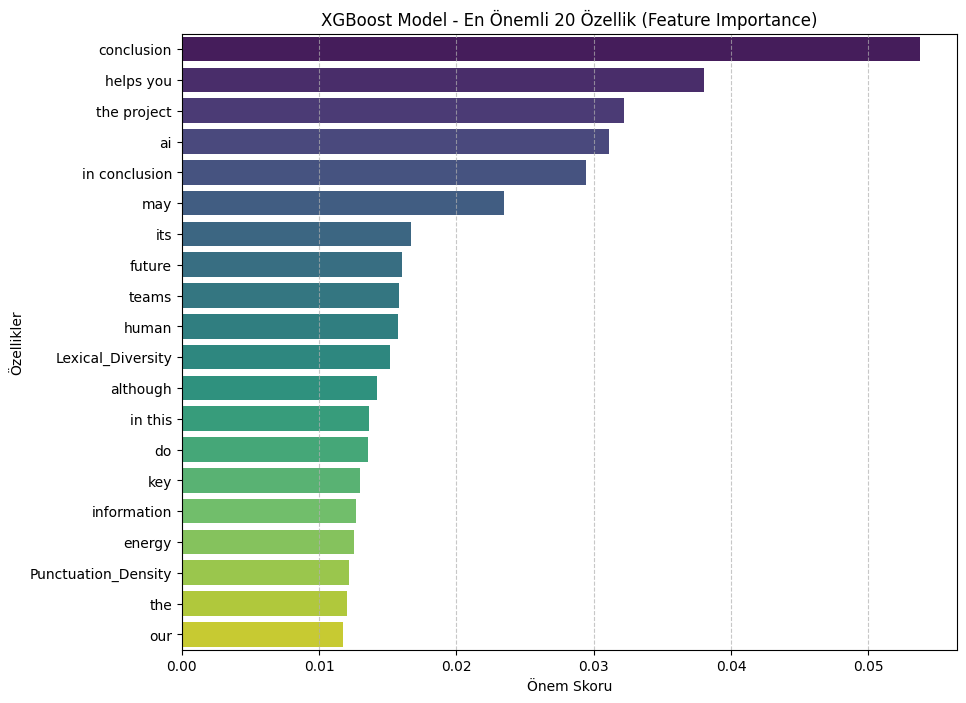


=== XGBoost Model Performance Table (Before Hyperparameter tuning) ===
Accuracy : 0.9084
Precision: 0.9085
Recall   : 0.9084
F1-Score : 0.9084

=== XGBoost Model Performance Table (After Hyperparameter tuning) ===
Accuracy : 0.9275
Precision: 0.9275
Recall   : 0.9275
F1-Score : 0.9275
------------------------------
Best Hyperparameters Found: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
------------------------------


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==========================================
# 1. BÖLÜM: Before Hyperparameter Tuning (Ham Model)
# ==========================================
print("XGBoost modeli varsayılan ayarlarla eğitiliyor...")

xgb_base = XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

xgb_base.fit(X_train_scaled, Y_train)

# Tahmin
y_pred_base = xgb_base.predict(X_test_scaled)

# Metrikler
acc_base = accuracy_score(Y_test, y_pred_base)
prec_base = precision_score(Y_test, y_pred_base, average='weighted')
rec_base = recall_score(Y_test, y_pred_base, average='weighted')
f1_base = f1_score(Y_test, y_pred_base, average='weighted')

# ==========================================
# 2. BÖLÜM: Hyperparameter Tuning (Grid Search)
# ==========================================
# Denenecek parametreler (Grid)
param_grid = {
    'n_estimators': [50, 100, 200],      # Ağaç sayısı
    'learning_rate': [0.01, 0.1, 0.2],   # Öğrenme hızı
    'max_depth': [3, 5, 7],              # Ağaç derinliği
    'subsample': [0.8, 1.0]              # Her ağaç için kullanılacak veri oranı
}

xgb_grid = XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# 3-Fold Cross Validation ile GridSearch
grid_search = GridSearchCV(
    estimator=xgb_grid,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, Y_train)

# En iyi modeli al
best_xgb = grid_search.best_estimator_
best_params = grid_search.best_params_

# ==========================================
# 3. BÖLÜM: After Hyperparameter Tuning (Optimize Model)
# ==========================================
# Tahmin
y_pred_tuned = best_xgb.predict(X_test_scaled)

# Metrikler
acc_tuned = accuracy_score(Y_test, y_pred_tuned)
prec_tuned = precision_score(Y_test, y_pred_tuned, average='weighted')
rec_tuned = recall_score(Y_test, y_pred_tuned, average='weighted')
f1_tuned = f1_score(Y_test, y_pred_tuned, average='weighted')

# ============================================================
# XGBoost Model - Feature Importance Analizi
# ============================================================

# 1. Özellik Önem Skorlarını Al
importance_scores = best_xgb.feature_importances_

# NOT: 'tfidf_With' değişkeninin önceki hücrelerde tanımlanmış olması gerekir.
try:
    tfidf_feature_names = tfidf_With.get_feature_names_out()
    manual_feature_names = ['Avg_Sentence_Length', 'Lexical_Diversity', 'Punctuation_Density', 'Capitalized_Ratio', 'Pronoun_Ratio', 'Num_Sentences']

    # İsimleri birleştir
    feature_names = np.array(list(tfidf_feature_names) + manual_feature_names)
except NameError:
    print("HATA: 'tfidf_With' değişkeni bulunamadı. Lütfen önceki hücreleri çalıştırın.")
    # Hata durumunda dummy isimler oluştur (Kodun çökmemesi için)
    feature_names = [f"Feature_{i}" for i in range(len(importance_scores))]

# 2. Veri Çerçevesine Dönüştür ve Sırala
xgb_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False)

# ÖNEMLİ DÜZELTME: Binlerce özellik varsa grafik kilitlenir.
# Sadece en önemli ilk 20 özelliği alıyoruz (.head(20))
xgb_imp_df_top20 = xgb_imp_df.head(20)

# 3. Görselleştirme (Bar Plot)
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=xgb_imp_df_top20, palette='viridis')

# Grafik Ayarları
plt.title('XGBoost Model - En Önemli 20 Özellik (Feature Importance)')
plt.xlabel('Önem Skoru')
plt.ylabel('Özellikler')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()

# ==========================================
# 4. BÖLÜM: Raporlama
# ==========================================
print("\n" + "="*50)
print("=== XGBoost Model Performance Table (Before Hyperparameter tuning) ===")
print("="*50)
print(f"Accuracy : {acc_base:.4f}")
print(f"Precision: {prec_base:.4f}")
print(f"Recall   : {rec_base:.4f}")
print(f"F1-Score : {f1_base:.4f}")

print("\n" + "="*50)
print("=== XGBoost Model Performance Table (After Hyperparameter tuning) ===")
print("="*50)
print(f"Accuracy : {acc_tuned:.4f}")
print(f"Precision: {prec_tuned:.4f}")
print(f"Recall   : {rec_tuned:.4f}")
print(f"F1-Score : {f1_tuned:.4f}")
print("-" * 30)
print(f"Best Hyperparameters Found: {best_params}")
print("-" * 30)